# Week 4 — CNN Classification & Segmentation‑Guided Classification


In [1]:
from pathlib import Path
DATA_PATH = Path(r"C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR")  

SPLITS_DIR = Path.cwd() / "wk3_splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

MASKS_ROOT = None 

SEED = 42
IMG_SIZE = 224
BATCH = 16
MODEL_NAME = "resnet18" 
LR = 1e-3
EPOCHS = 3 


In [2]:
import os, csv, random, math
import numpy as np
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)


Device: cpu


In [3]:
def _find_images(root: Path):
    exts = (".png",".jpg",".jpeg",".bmp",".tif",".tiff",".dcm")
    return [p for p in root.rglob("*") if p.suffix.lower() in exts]

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())
if DATA_PATH.exists():
    sample_imgs = _find_images(DATA_PATH)[:5]
    print("Sample images found:", len(sample_imgs))
    for s in sample_imgs:
        print(" -", s)
else:
    print("⚠️ Set DATA_PATH correctly in Config.")


DATA_PATH: C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR
Exists: True
Sample images found: 5
 - C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR\files\p18\p18000291\s55388853\04564240-d4e9e69c-1dd70a83-14b463cd-b7614743.dcm
 - C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR\files\p18\p18000291\s55388853\a17c02b3-7c360f2c-a07734a0-76867697-36d59d3d.dcm
 - C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR\files\p18\p18000291\s55388853\ed82a88d-499bed8a-de7539b2-417328ad-8aac20ee.dcm
 - C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR\files\p18\p18000379\s51062789\4885a037-6d0efe8b-97d2955b-eb046c9f-3f5d89b6.dcm
 - C:\Users\Maysoun\Downloads\MIMIC-CXR\MIMIC-CXR\files\p18\p18000379\s51062789\eac2b8fa-9245fe41-76c8951a-fe495dc0-a705cb9b.dcm


In [4]:
def _infer_label_from_path(p: Path):
    parts = [s.lower() for s in p.parts]
    if any("pneumonia" in s for s in parts):
        return 1
    if any("normal" in s for s in parts):
        return 0
    return None

def _read_existing_split(csv_path: Path):
    pairs = []
    if not csv_path or not csv_path.exists():
        return pairs
    with csv_path.open(newline="", encoding="utf-8") as f:
        r = csv.DictReader(f)
        path_col = None
        for cand in ("path","image","img","filepath","file","filename"):
            if cand in r.fieldnames:
                path_col = cand; break
        label_col = None
        for cand in ("label","y","target","class","cls"):
            if cand in r.fieldnames:
                label_col = cand; break
        for row in r:
            p = Path(row[path_col])
            y = int(row[label_col]) if label_col else _infer_label_from_path(p)
            if y is not None:
                pairs.append((p, y))
    return pairs

def _write_split(csv_path: Path, pairs):
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["path","label"])
        for p,y in pairs:
            w.writerow([str(p), int(y)])


In [5]:
from pathlib import Path

SPLITS_DIR = Path.cwd() / "wk3_splits"
SEED = 42
IMG_SIZE = 224
BATCH = 16
MODEL_NAME = "resnet18"
LR = 1e-3
EPOCHS = 3

RSNA_LABELS = Path(r"C:\Users\Maysoun\Downloads\rsna-pneumonia-detection-challenge\stage_2_train_labels.csv")
RSNA_IMAGES_DIR = Path(r"C:\Users\Maysoun\Downloads\rsna-pneumonia-detection-challenge\stage_2_train_images")

DATA_PATH = None
LABELS_CSV = None
MASKS_ROOT = None


In [6]:
import pandas as pd, csv, random
from pathlib import Path
from sklearn.model_selection import train_test_split

assert RSNA_LABELS.exists(), f"Missing RSNA labels: {RSNA_LABELS}"
assert RSNA_IMAGES_DIR.exists(), f"Missing RSNA images dir: {RSNA_IMAGES_DIR}"

df = pd.read_csv(RSNA_LABELS)

agg = df.groupby("patientId")["Target"].max().reset_index().rename(columns={"Target":"label"})
agg["label"] = agg["label"].astype(int)

def _resolve(pid: str):
    p = RSNA_IMAGES_DIR / f"{pid}.dcm"
    if p.exists(): return p
    for d in RSNA_IMAGES_DIR.iterdir():
        if d.is_dir():
            cand = d / f"{pid}.dcm"
            if cand.exists(): return cand
    return None

pairs = []
for _, row in agg.iterrows():
    p = _resolve(row["patientId"])
    if p is not None:
        pairs.append((p, int(row["label"])))

if len(pairs) < 50:
    raise RuntimeError("RSNA: too few images resolved. Check RSNA_IMAGES_DIR.")

random.seed(SEED)
pairs_sorted = sorted(pairs, key=lambda t: str(t[0]))
X = [str(p) for p,_ in pairs_sorted]
y = [int(lbl) for _,lbl in pairs_sorted]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

train_pairs = [(Path(p), int(l)) for p,l in zip(X_train,y_train)]
val_pairs   = [(Path(p), int(l)) for p,l in zip(X_val,  y_val)]
test_pairs  = [(Path(p), int(l)) for p,l in zip(X_test, y_test)]

# save CSVs so the rest of the notebook reuses them automatically
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
for name, pairs_list in [("train",train_pairs),("val",val_pairs),("test",test_pairs)]:
    out = SPLITS_DIR / f"{name}.csv"
    with out.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["path","label"])
        for p,yv in pairs_list: w.writerow([str(p), int(yv)])

print(f"RSNA splits → train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}")


RSNA splits → train=18678, val=4003, test=4003


In [7]:
len(train_pairs), len(val_pairs), len(test_pairs)


(18678, 4003, 4003)

In [8]:
import pandas as pd

df_boxes = pd.read_csv(RSNA_LABELS)
df_boxes = df_boxes[df_boxes["Target"] == 1].dropna(subset=["x","y","width","height"])

boxes_by_pid = {}
for _, r in df_boxes.iterrows():
    pid = r["patientId"]
    boxes_by_pid.setdefault(pid, []).append((
        float(r["x"]), float(r["y"]), float(r["width"]), float(r["height"])
))

print("Images with boxes:", len(boxes_by_pid))


Images with boxes: 6012


In [9]:
# FAST MODE
FAST = True
if FAST:
    N_TR, N_VAL, N_TE = 2000, 500, 500 
    train_pairs = train_pairs[:N_TR]
    val_pairs   = val_pairs[:N_VAL]
    test_pairs  = test_pairs[:N_TE]

    IMG_SIZE = 160   
    BATCH    = 8
    EPOCHS   = 1    


In [10]:
from pathlib import Path
from PIL import Image
import numpy as np

CACHE_DIR = Path("rsna_jpg_cache"); CACHE_DIR.mkdir(exist_ok=True)

def _load_image_any(p: Path):
    p = Path(p)
    if p.suffix.lower() == ".dcm":
        jpg = CACHE_DIR / f"{p.stem}.jpg"
        if jpg.exists():
            return Image.open(jpg).convert("RGB")
        import pydicom
        ds = pydicom.dcmread(str(p))
        arr = ds.pixel_array.astype(np.float32)
        mn, mx = float(arr.min()), float(arr.max())
        arr = (255.0 * (arr - mn) / max(1e-6, (mx - mn))).clip(0,255).astype(np.uint8)
        img = Image.fromarray(arr).convert("RGB")
        try: img.save(jpg, "JPEG", quality=90)
        except: pass
        return img
    return Image.open(p).convert("RGB")

In [12]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

assert 'train_pairs' in globals() and len(train_pairs)>0, "Run the RSNA splits cell first."

IMG_SIZE = globals().get('IMG_SIZE', 160)
BATCH    = globals().get('BATCH', 8)
CACHE_DIR = Path("rsna_jpg_cache"); CACHE_DIR.mkdir(exist_ok=True)

def _load_image_any(p: Path):
    p = Path(p)
    if p.suffix.lower() == ".dcm":
        jpg = CACHE_DIR / f"{p.stem}.jpg"
        if jpg.exists():
            return Image.open(jpg).convert("RGB")
        import pydicom
        ds = pydicom.dcmread(str(p))
        arr = ds.pixel_array.astype(np.float32)
        mn, mx = float(arr.min()), float(arr.max())
        arr = (255.0 * (arr - mn) / max(1e-6, (mx - mn))).clip(0,255).astype(np.uint8)
        img = Image.fromarray(arr).convert("RGB")
        try: img.save(jpg, "JPEG", quality=90)  # cache for later
        except: pass
        return img
    return Image.open(p).convert("RGB")

class ClassificationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform
    def __len__(self): 
        return len(self.pairs)
    def __getitem__(self, idx):
        path, lbl = self.pairs[idx]
        img = _load_image_any(path)
        if self.transform:
            img = self.transform(img)
        return img, int(lbl), str(path)

# minimal, fast transforms
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# DataLoaders
pin = torch.cuda.is_available()
train_ds = ClassificationDataset(train_pairs, transform=train_tfms)
val_ds   = ClassificationDataset(val_pairs,   transform=eval_tfms)
test_ds  = ClassificationDataset(test_pairs,  transform=eval_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=pin)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=pin)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=pin)

print("Batches →", "train", len(train_dl), "val", len(val_dl), "test", len(test_dl))


Batches → train 250 val 63 test 63


In [13]:
import torch, torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_classifier(model_name: str, num_classes: int, pretrained=True):
    m = model_name.lower()
    if m == "resnet18":
        try:
            w = models.ResNet18_Weights.DEFAULT if pretrained else None
            net = models.resnet18(weights=w)
        except Exception:
            net = models.resnet18(pretrained=pretrained)
        net.fc = nn.Linear(net.fc.in_features, 2)
        return net
    if m in ("efficientnet_b0","efficientnetb0","enb0"):
        try:
            w = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            net = models.efficientnet_b0(weights=w)
        except Exception:
            net = models.efficientnet_b0(pretrained=pretrained)
        net.classifier[-1] = nn.Linear(net.classifier[-1].in_features, 2)
        return net
    raise ValueError(model_name)

model = make_classifier("resnet18", num_classes=2, pretrained=True).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss=0.0; y_true=[]; y_pred=[]; y_prob=[]
    for i,(x,y,_) in enumerate(dl, 1):
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out,y)
        if train:
            loss.backward(); opt.step()
        total_loss += loss.item()*x.size(0)
        prob = torch.softmax(out,1)[:,1].detach().cpu().numpy()
        pred = out.argmax(1).detach().cpu().numpy()
        y_prob += prob.tolist(); y_pred += pred.tolist(); y_true += y.cpu().numpy().tolist()
        if i % 20 == 0:
            acc = accuracy_score(y_true, y_pred)
            print(f"{'train' if train else 'val'} step {i}/{len(dl)}  acc={acc:.3f}", end="\r")
    n = len(dl.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    try: auc = roc_auc_score(y_true, y_prob)
    except: auc = float("nan")
    return total_loss/max(1,n), acc, prec, rec, f1, auc

for ep in range(EPOCHS):
    tr = run_epoch(train_dl, True)
    va = run_epoch(val_dl,   False) if len(val_ds)>0 else None
    msg = f"Epoch {ep+1}/{EPOCHS} | train: loss {tr[0]:.4f} acc {tr[1]:.3f} f1 {tr[4]:.3f} auc {tr[5]:.3f}"
    if va: msg += f" | val: acc {va[1]:.3f} f1 {va[4]:.3f} auc {va[5]:.3f}"
    print("\n"+msg)

torch.save(model.state_dict(), "cnn_resnet18_fast.pth")
print("Saved → cnn_resnet18_fast.pth")

val step 60/63  acc=0.767.750
Epoch 1/1 | train: loss 0.5604 acc 0.751 f1 0.362 auc 0.704 | val: acc 0.774 f1 0.459 auc 0.785
Saved → cnn_resnet18_fast.pth


TEST → acc=0.784, prec=0.517, rec=0.282, f1=0.365, auc=0.778


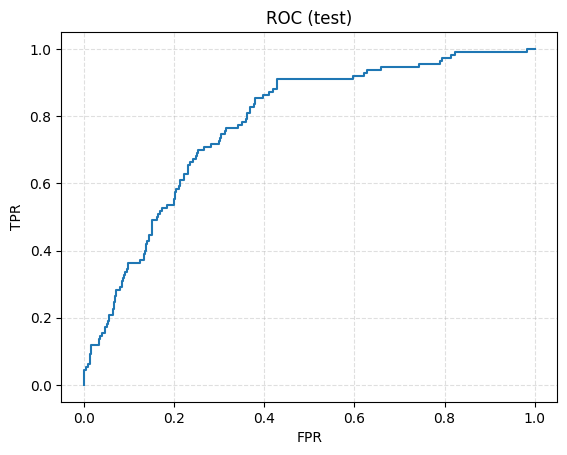

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

_, te_acc, te_prec, te_rec, te_f1, te_auc = run_epoch(test_dl, False)
print(f"TEST → acc={te_acc:.3f}, prec={te_prec:.3f}, rec={te_rec:.3f}, f1={te_f1:.3f}, auc={te_auc:.3f}")

y_true, y_prob = [], []
model.eval()
with torch.no_grad():
    for x,y,_ in test_dl:
        x = x.to(DEVICE)
        prob = torch.softmax(model(x),1)[:,1].cpu().numpy()
        y_prob += prob.tolist(); y_true += y.numpy().tolist()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(); plt.plot(fpr,tpr); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (test)"); plt.grid(True, ls="--", alpha=0.4)
plt.show()


In [15]:
import pandas as pd
df_boxes = pd.read_csv(RSNA_LABELS)
df_boxes = df_boxes[df_boxes["Target"] == 1].dropna(subset=["x","y","width","height"])
boxes_by_pid = {}
for _, r in df_boxes.iterrows():
    boxes_by_pid.setdefault(r["patientId"], []).append((float(r["x"]), float(r["y"]), float(r["width"]), float(r["height"])))
print("Images with boxes:", len(boxes_by_pid))

Images with boxes: 6012


In [16]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import torch, torch.nn as nn

# subsample positives with boxes for speed
pos_with_boxes = [(p,y) for p,y in train_pairs if p.stem in boxes_by_pid][:800]

class SegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.items = pairs; self.t = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        import pydicom, numpy as np
        ds = pydicom.dcmread(str(p))
        arr = ds.pixel_array.astype(np.float32)
        mn, mx = float(arr.min()), float(arr.max())
        arr = (255.0*(arr-mn)/max(1e-6,(mx-mn))).clip(0,255).astype(np.uint8)
        img = Image.fromarray(arr).convert("RGB")
        mask = Image.new("L", img.size, 0)
        draw = ImageDraw.Draw(mask)
        for x,yb,w,h in boxes_by_pid[p.stem]:
            draw.rectangle([x, yb, x+w, yb+h], fill=255)
        img = eval_tfms(img)
        mask = transforms.Resize((IMG_SIZE, IMG_SIZE))(mask)
        mask = transforms.ToTensor()(mask)
        return img, mask

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.m = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True)
        )
    def forward(self,x): return self.m(x)

class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1=DoubleConv(3,32); self.p1=nn.MaxPool2d(2)
        self.d2=DoubleConv(32,64); self.p2=nn.MaxPool2d(2)
        self.b =DoubleConv(64,128)
        self.u2=nn.ConvTranspose2d(128,64,2,2); self.c2=DoubleConv(128,64)
        self.u1=nn.ConvTranspose2d(64,32,2,2);  self.c1=DoubleConv(64,32)
        self.out=nn.Conv2d(32,1,1)
        self.cls=nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128,2))
    def forward(self,x):
        d1=self.d1(x); d2=self.d2(self.p1(d1)); b=self.b(self.p2(d2))
        cls=self.cls(b)
        u2=self.u2(b); c2=self.c2(torch.cat([u2,d2],1))
        u1=self.u1(c2); c1=self.c1(torch.cat([u1,d1],1))
        seg=self.out(c1)
        return seg, cls

seg_dl = DataLoader(SegDataset(pos_with_boxes, eval_tfms), batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=pin)
unet = UNetSmall().to(DEVICE)
opt2 = torch.optim.AdamW(unet.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss(); ce = nn.CrossEntropyLoss()

for ep in range(1):  # one quick epoch
    unet.train(); total=0.0
    for img,mask in seg_dl:
        img,mask = img.to(DEVICE), mask.to(DEVICE)
        opt2.zero_grad()
        seg, logits = unet(img)
        # pseudo labels for cls: any mask pixel > 0 means pneumonia present (1)
        cls = (mask.mean(dim=[2,3])>0.01).long().squeeze(1)
        loss = bce(seg, mask) + 0.1*ce(logits, cls)
        loss.backward(); opt2.step()
        total += loss.item()*img.size(0)
    print(f"UNet small (1 epoch) loss={total/max(1,len(pos_with_boxes)):.4f}")

torch.save(unet.state_dict(), "unet_small_fast.pth")
print('Saved → unet_small_fast.pth')


UNet small (1 epoch) loss=0.3917
Saved → unet_small_fast.pth
